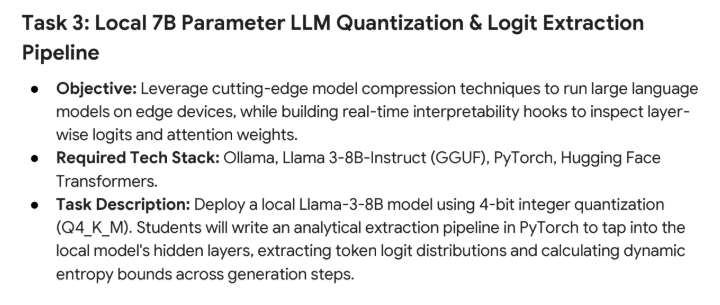

**Install Required Libraries**

In [ ]:
!pip install llama-cpp-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 MB 11.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.0 MB/s eta 0:00:00
  Created wheel for llama-cpp-python: filename=llama_cpp_python-0.3.34-py3-none-linux_x86_64.whl size=20319372 sha256=2e7cca3b8152e0ab2f56d25634491ae5203d6c4746bd3f6f4086edcf215d5726
  Stored in directory: /root/.cache/pip/wheels/4a/10/e7/0eb9b120f1640844f33562a3964c5b18b67de1d66d3f9530e8
Successfully built llama-cpp-python


In [ ]:
!pip install numpy pandas matplotlib torch

**Load Local GGUF Model**

In [ ]:
from llama_cpp import Llama
import os

# Ensure the models directory exists
os.makedirs("models", exist_ok=True)
model_path = "models/llama-3-8b-instruct-q4_k_m.gguf"

# Download the model if it doesn't exist
if not os.path.exists(model_path):
    print("Downloading model...")
    from huggingface_hub import hf_hub_download
    hf_hub_download(
        repo_id="MaziyarPanahi/Llama-3-8B-Instruct-v0.1-GGUF",
        filename="Llama-3-8B-Instruct-v0.1.Q4_K_M.gguf",
        local_dir="models",
        local_dir_use_symlinks=False
    )
    # Rename to match the expected path in your original code
    os.rename("models/Llama-3-8B-Instruct-v0.1.Q4_K_M.gguf", model_path)

model = Llama(
    model_path=model_path,
    n_ctx=4096,
    n_threads=8,
    n_gpu_layers=-1,
    logits_all=True,
    verbose=False
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Llama-3-8B-Instruct-v0.1.Q4_K_M.gguf: reconstructing file:   0%|          |  0.00B / 4.92GB            

Llama-3-8B-Instruct-v0.1.Q4_K_M.gguf: downloading bytes:           |  0.00B            

**Generate Text**

In [ ]:
prompt = """
Explain how reinforcement learning can be used
for autonomous robots in manufacturing.
"""

# Added logprobs=10 to ensure we get probability data for entropy calculation
response = model(
    prompt,
    max_tokens=100,
    temperature=0.7,
    top_p=0.9,
    logprobs=10
)

generated_text = response["choices"][0]["text"]

print(generated_text)

---

Reinforcement learning (RL) is a type of machine learning that enables autonomous robots to learn from trial and error. In the context of manufacturing, RL can be used to train robots to perform complex tasks, such as assembly, welding, and material handling, without human intervention. Here's how:

**Problem Statement:**
In a manufacturing environment, robots are often used to perform repetitive tasks, such as assembly, welding, and material handling. However, these tasks can be complex and require


**Tokenize the Prompt**

In [ ]:
tokens = model.tokenize(
    prompt.encode("utf-8")
)

print("Number of tokens:", len(tokens))
print("Tokens:", tokens[:20])

Number of tokens: 17
Tokens: [128000, 198, 849, 21435, 1268, 72378, 6975, 649, 387, 1511, 198, 2000, 39293, 29807, 304, 15266, 627]


**Obtain Logits**

In [ ]:
import torch

def logits_to_probabilities(logits):

    logits = torch.tensor(
        logits,
        dtype=torch.float32
    )

    probabilities = torch.softmax(
        logits,
        dim=-1
    )

    return probabilities

**Calculate Token Entropy**

In [ ]:
def calculate_entropy(probabilities):

    probabilities = torch.clamp(
        probabilities,
        min=1e-12
    )

    entropy = -torch.sum(
        probabilities *
        torch.log(probabilities)
    )

    return entropy.item()

**Calculate Normalized Entropy**

In [ ]:
def normalized_entropy(probabilities):

    entropy = -torch.sum(
        probabilities *
        torch.log(
            probabilities.clamp(min=1e-12)
        )
    )

    vocab_size = probabilities.shape[-1]

    max_entropy = torch.log(
        torch.tensor(
            vocab_size,
            dtype=torch.float32
        )
    )

    return (
        entropy / max_entropy
    ).item()

**Dynamic Entropy Analysis**

In [ ]:
import torch

# Initialize the history list
entropy_history = []

# Ensure logits_sequence exists from the response parsing
if 'logits_sequence' in globals():
    for step in range(len(logits_sequence)):
        # Extract the numeric values (log-probabilities) from the dictionary
        step_dict = logits_sequence[step]
        logits_values = list(step_dict.values())

        # Convert these values to probabilities
        probabilities = logits_to_probabilities(logits_values)

        # Calculate the normalized entropy for this generation step
        entropy = normalized_entropy(probabilities)
        entropy_history.append(entropy)

    print(f"Successfully calculated entropy for {len(entropy_history)} steps.")
    print("First 5 steps:", [round(e, 3) for e in entropy_history[:5]])
else:
    print("Error: 'logits_sequence' not found. Please run cell OGt0jjEu2RJ3 first.")

Successfully calculated entropy for 100 steps.
First 5 steps: [0.812, 0.572, 0.197, 0.0, 0.0]


**Visualize Dynamic Entropy**

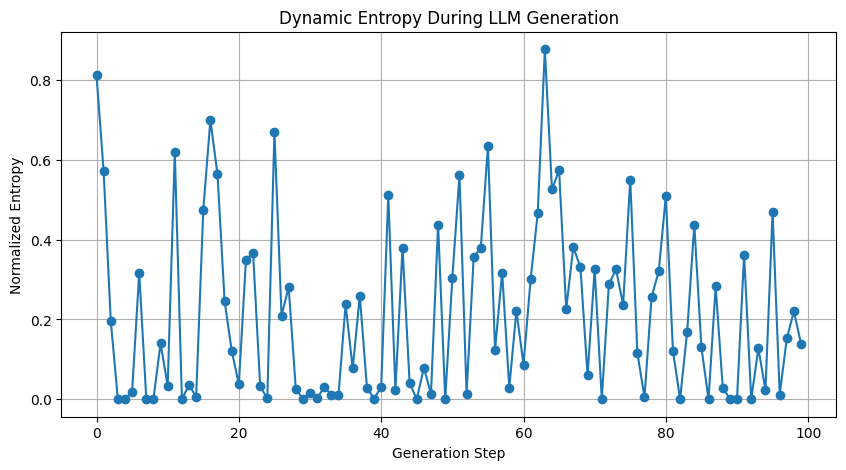

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    entropy_history,
    marker="o"
)

plt.xlabel("Generation Step")
plt.ylabel("Normalized Entropy")

plt.title(
    "Dynamic Entropy During LLM Generation"
)

plt.grid()

plt.show()

**Top-K Token Distribution**

In [ ]:
def top_k_predictions(logits, tokenizer, k=10):
    logits = torch.tensor(logits, dtype=torch.float32)
    probabilities = torch.softmax(logits, dim=-1)

    # Ensure k is not larger than the number of available logits
    actual_k = min(k, probabilities.shape[-1])

    values, indices = torch.topk(probabilities, actual_k)

    results = []
    for probability, token_id in zip(values, indices):
        # In llama-cpp-python logprobs, the index might correspond to the rank
        # if we are passing a list of top logprobs rather than the full vocab.
        # However, to be safe, we treat them as probabilities.
        results.append((str(token_id.item()), float(probability)))

    return results

In [ ]:
import torch

# We check for the last_step_logprobs which contains the most relevant data
if 'last_step_logprobs' in globals():
    # Extract keys (tokens) and values (logprobs)
    tokens_list = list(last_step_logprobs.keys())
    logits_values = list(last_step_logprobs.values())

    # Convert logprobs to probabilities
    probs = torch.softmax(torch.tensor(logits_values), dim=-1)

    results = list(zip(tokens_list, probs.tolist()))

    print("Top 10 predictions for the analyzed step:")
    for token, probability in results:
        print(f"{repr(token):<20} {probability:.4f}")
else:
    print("Error: 'last_step_logprobs' variable not found. Please ensure the generation cell has run.")

Top 10 predictions for the analyzed step:
' require'           0.9440
' may'               0.0190
' involve'           0.0137
' dynamic'           0.0062
' varied'            0.0042
' challenging'       0.0041
' vary'              0.0028
' prone'             0.0022
' error'             0.0021
' variable'          0.0016


In [ ]:
import torch

# Extract the numeric values from the logits dictionary
if isinstance(logits, dict):
    logits_values = list(logits.values())
else:
    logits_values = logits

results = top_k_predictions(
    logits_values,
    model,
    k=10
)

print("Top 10 candidates for the current step:")
for token, probability in results:
    print(f"{repr(token):<20} {probability:.4f}")

Top 10 candidates for the current step:
'0'                  0.4400
'1'                  0.2614
'2'                  0.1376
'3'                  0.0624
'4'                  0.0555
'5'                  0.0432


**Top-K Probability Graph**

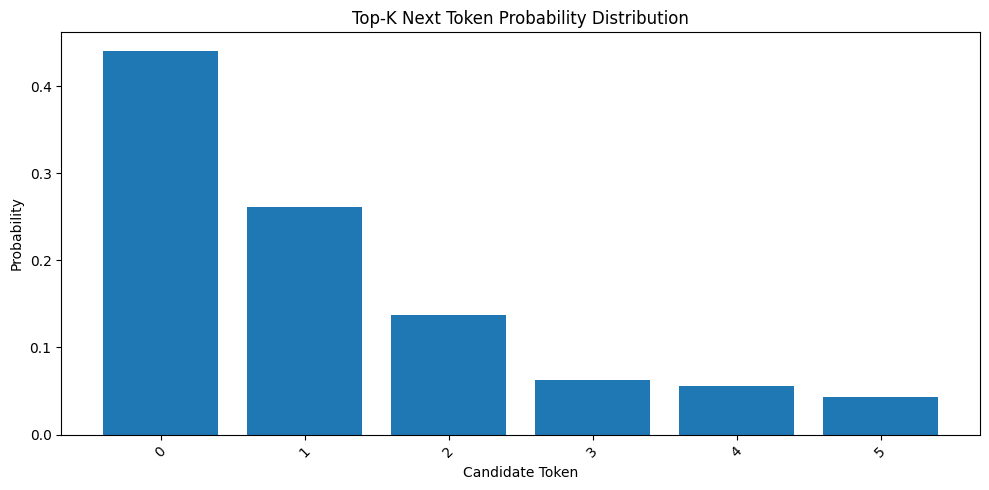

In [ ]:
tokens = [
    item[0]
    for item in results
]

probabilities = [
    item[1]
    for item in results
]

plt.figure(figsize=(10, 5))

plt.bar(
    tokens,
    probabilities
)

plt.xlabel("Candidate Token")
plt.ylabel("Probability")

plt.title(
    "Top-K Next Token Probability Distribution"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Dynamic Entropy Bound**

In [ ]:
def entropy_bound(entropy):

    if entropy < 0.25:
        return "HIGH CONFIDENCE"

    elif entropy < 0.60:
        return "MODERATE CONFIDENCE"

    else:
        return "HIGH UNCERTAINTY"

In [ ]:
for i, entropy in enumerate(
    entropy_history
):

    print(
        f"Step {i+1}: "
        f"{entropy:.3f} → "
        f"{entropy_bound(entropy)}"
    )

Step 1: 0.812 → HIGH UNCERTAINTY
Step 2: 0.572 → MODERATE CONFIDENCE
Step 3: 0.197 → HIGH CONFIDENCE
Step 4: 0.000 → HIGH CONFIDENCE
Step 5: 0.000 → HIGH CONFIDENCE
Step 6: 0.018 → HIGH CONFIDENCE
Step 7: 0.317 → MODERATE CONFIDENCE
Step 8: 0.000 → HIGH CONFIDENCE
Step 9: 0.000 → HIGH CONFIDENCE
Step 10: 0.140 → HIGH CONFIDENCE
Step 11: 0.033 → HIGH CONFIDENCE
Step 12: 0.619 → HIGH UNCERTAINTY
Step 13: 0.000 → HIGH CONFIDENCE
Step 14: 0.036 → HIGH CONFIDENCE
Step 15: 0.006 → HIGH CONFIDENCE
Step 16: 0.473 → MODERATE CONFIDENCE
Step 17: 0.700 → HIGH UNCERTAINTY
Step 18: 0.564 → MODERATE CONFIDENCE
Step 19: 0.246 → HIGH CONFIDENCE
Step 20: 0.121 → HIGH CONFIDENCE
Step 21: 0.037 → HIGH CONFIDENCE
Step 22: 0.349 → MODERATE CONFIDENCE
Step 23: 0.367 → MODERATE CONFIDENCE
Step 24: 0.032 → HIGH CONFIDENCE
Step 25: 0.002 → HIGH CONFIDENCE
Step 26: 0.670 → HIGH UNCERTAINTY
Step 27: 0.209 → HIGH CONFIDENCE
Step 28: 0.281 → MODERATE CONFIDENCE
Step 29: 0.026 → HIGH CONFIDENCE
Step 30: 0.000 → HIG